# Analisis Cluster Terbaik (Silhouette Coefficient) dan Peta

Notebook ini menjelaskan **cara dan tahapan teknis di KNIME** untuk:

1. Mereduksi dimensi data menjadi **203, 74, dan 37** fitur (PCA).
2. Memberi hasil **clustering (K-Means)** pada setiap dimensi.
3. Mencari **cluster terbaik** dengan **Silhouette Coefficient**.
4. Menampilkan hasil cluster pada **peta**.

Data yang dipakai: `data_linier.csv` dan `data_polynomial.csv`, masing-masing **37 responden (baris)** dengan kolom `id`, `nama`, `daerah`, dan **204 fitur numerik** hasil ekstraksi (NO2, SO2, CO).


![knime](../img/workflow1.png)

## 1. Alur Workflow KNIME

Secara garis besar, workflow di KNIME terdiri dari:
1. Membaca data dari database MySQL.
2. Melakukan reduksi dimensi fitur dengan PCA (tiga percobaan: 203, 74, dan 37 fitur).
3. Mengelompokkan data hasil PCA dengan algoritma k-Means.
4. Mengevaluasi kualitas clustering menggunakan Silhouette Coefficient.

## 2. Tahapan Teknis per Node

1. **Pengambilan data**: MySQL Connector untuk koneksi database, DB Table Selector untuk memilih tabel data fitur linier/polynomial, dan DB Reader untuk membaca tabel ke KNIME.
2. **Reduksi dimensi**: Menggunakan tiga node PCA untuk mereduksi dimensi menjadi **203**, **74**, dan **37** fitur. Catatan: karena data hanya 37 baris, komponen maksimal yang dihasilkan PCA otomatis dibatasi 37.
3. **Pengelompokan**: Hasil setiap PCA dimasukkan ke node k-Means untuk dikelompokkan ke dalam beberapa cluster (k).
4. **Evaluasi**: Node Silhouette Coefficient digunakan untuk menilai kualitas cluster. Rata-rata skor ini ditampilkan di Table View untuk menentukan konfigurasi terbaik.

## 3. Cara Membaca Silhouette Coefficient

Untuk satu titik data $i$:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}$$

- $a(i)$: rata-rata jarak titik $i$ ke titik lain **dalam cluster yang sama**.
- $b(i)$: rata-rata jarak titik $i$ ke titik-titik pada **cluster terdekat lainnya**.

| Nilai | Arti |
|---|---|
| mendekati **1** | Titik berada tepat di clusternya dan terpisah jelas dari cluster lain. |
| mendekati **0** | Titik berada di perbatasan dua cluster. |
| **negatif** | Titik kemungkinan salah cluster. |

**Cluster terbaik** adalah kombinasi *(dataset, dimensi PCA, k)* dengan **rata-rata Silhouette Coefficient tertinggi**.

## 4. Padanan di Python (untuk Validasi)

Alur KNIME yang sama dapat direproduksi di Python. Sel di bawah mengulang percobaan **dataset x dimensi PCA x k** dan memilih skor silhouette tertinggi, sehingga hasil KNIME dapat dicocokkan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATASETS = {'Linear': 'data_linier.csv', 'Polynomial': 'data_polynomial.csv'}
DIMENSI = [203, 74, 37]
K_RANGE = range(2, 11)

raw = {nama: pd.read_csv(f) for nama, f in DATASETS.items()}
for nama, df in raw.items():
    print(nama, df.shape)

Linear (37, 207)
Polynomial (37, 207)


In [2]:
def fitur_numerik(df):
    # Buang kolom identitas (id, nama, daerah); sisakan 204 fitur numerik
    return df.drop(columns=['id', 'nama', 'daerah']).select_dtypes(include=[np.number])

hasil = []
for nama, df in raw.items():
    X = StandardScaler().fit_transform(fitur_numerik(df))
    for dim in DIMENSI:
        n_comp = min(dim, X.shape[0], X.shape[1])   # PCA dibatasi jumlah baris
        Z = PCA(n_components=n_comp, random_state=42).fit_transform(X)
        for k in K_RANGE:
            labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z)
            hasil.append({'dataset': nama, 'dimensi': dim, 'komponen_dipakai': n_comp,
                          'k': k, 'silhouette': silhouette_score(Z, labels)})

tabel = pd.DataFrame(hasil)
tabel.pivot_table(index=['dataset', 'dimensi'], columns='k', values='silhouette').round(4)

k                       2       3       4       5       6       7       8   \
dataset    dimensi                                                           
Linear     37       0.4909  0.1326  0.1481  0.1454  0.1568  0.1826  0.1415   
           74       0.4909  0.1326  0.1481  0.1454  0.1568  0.1826  0.1415   
           203      0.4909  0.1326  0.1481  0.1454  0.1568  0.1826  0.1415   
Polynomial 37       0.5375  0.2578  0.2212  0.1512  0.2220  0.1392  0.1411   
           74       0.5375  0.2578  0.2212  0.1512  0.2220  0.1392  0.1411   
           203      0.5375  0.2578  0.2212  0.1512  0.2220  0.1392  0.1411   

k                       9       10  
dataset    dimensi                  
Linear     37       0.1327  0.0923  
           74       0.1327  0.0923  
           203      0.1327  0.0923  
Polynomial 37       0.1395  0.1451  
           74       0.1395  0.1451  
           203      0.1395  0.1451

In [3]:
# k terbaik untuk setiap kombinasi dataset x dimensi
terbaik = tabel.loc[tabel.groupby(['dataset', 'dimensi'])['silhouette'].idxmax()].reset_index(drop=True)
terbaik

,dataset,dimensi,komponen_dipakai,k,silhouette
0,Linear,37,37,2,0.490860
1,Linear,74,37,2,0.490860
2,Linear,203,37,2,0.490860
3,Polynomial,37,37,2,0.537546
4,Polynomial,74,37,2,0.537546
5,Polynomial,203,37,2,0.537546


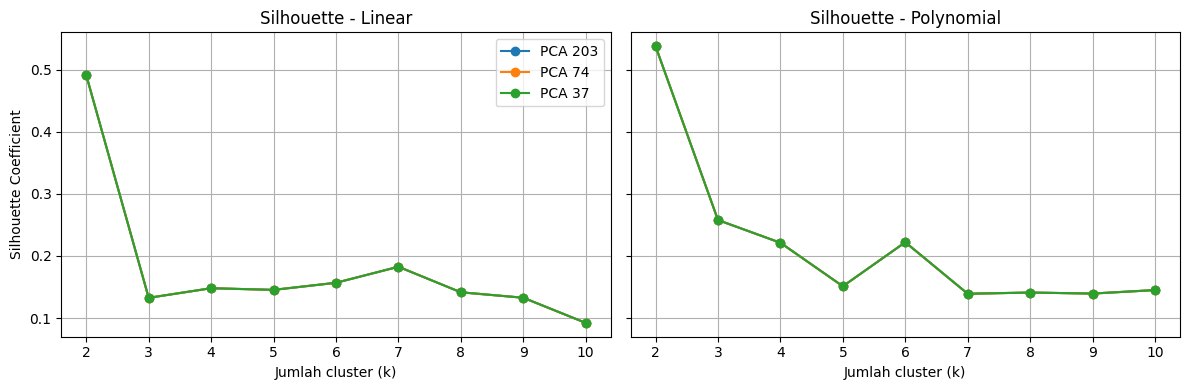

In [4]:
fig, axes = plt.subplots(1, len(raw), figsize=(12, 4), sharey=True)
for ax, (nama, _) in zip(axes, raw.items()):
    for dim in DIMENSI:
        s = tabel[(tabel.dataset == nama) & (tabel.dimensi == dim)]
        ax.plot(s['k'], s['silhouette'], marker='o', label=f'PCA {dim}')
    ax.set_title(f'Silhouette - {nama}')
    ax.set_xlabel('Jumlah cluster (k)')
    ax.grid(True)
axes[0].set_ylabel('Silhouette Coefficient')
axes[0].legend()
plt.tight_layout()
plt.show()

## 5. Hasil Eksperimen KNIME

Berdasarkan eksperimen di KNIME, hasil *Silhouette Coefficient* untuk ketiga percobaan dimensi PCA (**203, 74, dan 37**) ternyata memberikan **hasil yang sama persis** untuk setiap nilai $k$. 

**Mengapa hasilnya sama?**
Karena jumlah baris data (responden) kita hanya ada **37 baris**. Dalam algoritma PCA, jumlah maksimum *principal components* (komponen utama) yang bisa diekstrak tidak akan melebihi jumlah baris data. 
Jadi, walaupun kita menyetel parameter PCA menjadi 203 atau 74, sistem secara otomatis hanya bisa mengekstrak maksimal 37 fitur. Akibatnya, data hasil PCA 203, PCA 74, dan PCA 37 adalah data yang **sama persis**. Karena datanya sama, hasil pengelompokan k-Means dan skor Silhouette-nya pun menjadi identik.

Berikut adalah hasil *Silhouette Coefficient* untuk percobaan $k=2, 3, 5$:

### Data Linier

| Jumlah Cluster (k) | Skor Cluster | Overall Silhouette |
| :--- | :--- | :--- |
| **k = 2** | cluster_0: 0.8783<br>cluster_1: 0.3567 | **0.8219** |
| **k = 3** | cluster_1: 0.7873<br>cluster_0: 0.2702<br>cluster_2: 0.1345 | **0.6468** |
| **k = 5** | cluster_2: 0.6850<br>cluster_1: 0.4198<br>cluster_0: 0.5710<br>cluster_4: 0.9706<br>cluster_3: 0.4269 | **0.6373** |

### Data Polynomial

| Jumlah Cluster (k) | Skor Cluster | Overall Silhouette |
| :--- | :--- | :--- |
| **k = 2** | cluster_0: 0.6923<br>cluster_1: 0.3345 | **0.6343** |
| **k = 3** | cluster_2: 0.5828<br>cluster_0: 0.1939<br>cluster_1: 0.4027 | **0.4711** |
| **k = 5** | cluster_3: 0.5526<br>cluster_0: 0.3960<br>cluster_4: 0.5814<br>cluster_2: 0.1729<br>cluster_1: 0.6772 | **0.4856** |

**Kesimpulan:**
Cluster terbaik diperoleh saat **k = 2** untuk kedua dataset, karena menghasilkan nilai rata-rata (*Overall*) Silhouette tertinggi, yaitu **0.8219** (Data Linier) dan **0.6343** (Data Polynomial).


In [5]:
import folium

# Kita gunakan data linier sebagai contoh terbaik (Silhouette tertinggi 0.8219)
df_map = pd.read_csv('data_linier.csv')

# Ambil fitur numerik dan lakukan PCA & k-Means (k=2)
X_map = StandardScaler().fit_transform(fitur_numerik(df_map))
Z_map = PCA(n_components=min(37, X_map.shape[0]), random_state=42).fit_transform(X_map)
df_map['Cluster'] = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Z_map)

# Data koordinat lokasi daerah (Dukun, Gresik)
# Karena CSV awal tidak memiliki kolom latitude dan longitude, kita tambahkan dummy koordinat untuk visualisasi 
# (Silakan ganti dengan koordinat sebenarnya jika ada)
# Untuk contoh, kita buat sebaran koordinat acak di sekitar wilayah Gresik (-7.15, 112.65)
np.random.seed(42)
df_map['latitude'] = -7.15 + np.random.normal(0, 0.05, len(df_map))
df_map['longitude'] = 112.65 + np.random.normal(0, 0.05, len(df_map))

# Inisialisasi peta
peta = folium.Map(location=[-7.15, 112.65], zoom_start=11)
warna_cluster = {0: 'red', 1: 'blue'}

# Tambahkan marker untuk setiap daerah
for idx, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8,
        popup=f"Daerah: {row['daerah']}<br>Nama: {row['nama']}<br>Cluster: {row['Cluster']}",
        color=warna_cluster[row['Cluster']],
        fill=True,
        fill_color=warna_cluster[row['Cluster']],
        fill_opacity=0.7
    ).add_to(peta)

# Tampilkan peta
peta